Importing Libraries

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

Data collection and processing


In [33]:
#Loading the csv data into pandas DF

gold_data = pd.read_csv('gold price data.csv')


In [34]:
gold_data.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [35]:
gold_data.tail()

,Date,SPX,GLD,USO,SLV,EUR/USD
2285,5/8/2018,2671.919922,124.589996,14.0600,15.5100,1.186789
2286,5/9/2018,2697.790039,124.330002,14.3700,15.5300,1.184722
2287,5/10/2018,2723.070068,125.180000,14.4100,15.7400,1.191753
2288,5/14/2018,2730.129883,124.489998,14.3800,15.5600,1.193118
2289,5/16/2018,2725.780029,122.543800,14.4058,15.4542,1.182033


In [36]:
#number of rows and columns
gold_data.shape

(2290, 6)

In [37]:
#Getting basic information about the data

gold_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [38]:
#checking the number of missing values

gold_data.isnull().sum()

,0
Date,0
SPX,0
GLD,0
USO,0
SLV,0
EUR/USD,0


In [39]:
#Getting the statistical measure of the data

gold_data.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


Finding the correlation:
  1. Positive correlation
  2. Negative correlation

In [40]:
gold_data['Date'] = pd.to_datetime(gold_data['Date'])
correlation = gold_data.drop('Date', axis=1).corr()

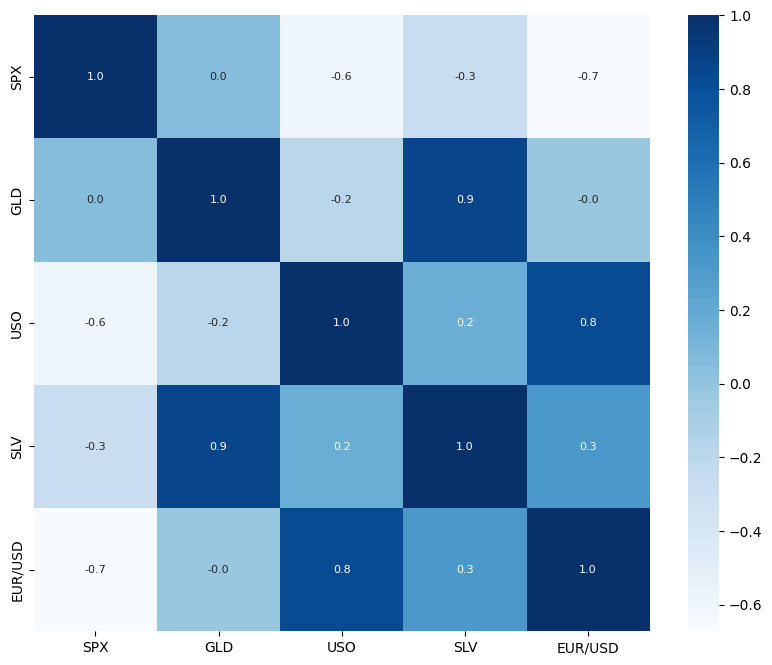

In [41]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, cbar=True, square=True, fmt='.1f',annot=True, annot_kws={'size':8},cmap='Blues')
plt.show()

In [42]:
#Correlation values of GLD

print(correlation['GLD'])

SPX        0.049345
GLD        1.000000
USO       -0.186360
SLV        0.866632
EUR/USD   -0.024375
Name: GLD, dtype: float64


/tmp/ipykernel_292/2118307685.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(gold_data['GLD'],color="Green")


<Axes: xlabel='GLD', ylabel='Density'>

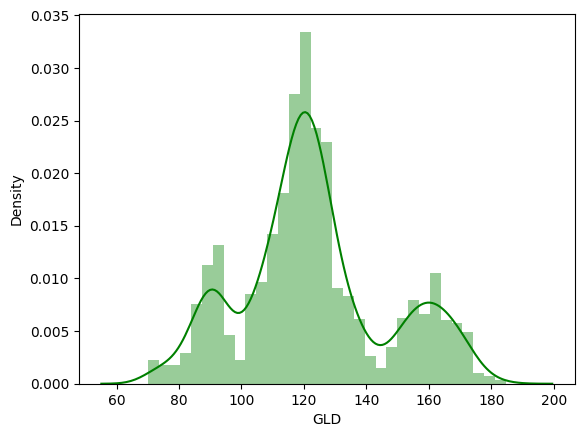

In [43]:
#Check the distribution of gold price

sns.distplot(gold_data['GLD'],color="Green")

Splitting the features and target

In [44]:
X = gold_data.drop(['Date','GLD'],axis=1)
Y = gold_data['GLD']

In [45]:
print(X)

              SPX        USO      SLV   EUR/USD
0     1447.160034  78.470001  15.1800  1.471692
1     1447.160034  78.370003  15.2850  1.474491
2     1411.630005  77.309998  15.1670  1.475492
3     1416.180054  75.500000  15.0530  1.468299
4     1390.189941  76.059998  15.5900  1.557099
...           ...        ...      ...       ...
2285  2671.919922  14.060000  15.5100  1.186789
2286  2697.790039  14.370000  15.5300  1.184722
2287  2723.070068  14.410000  15.7400  1.191753
2288  2730.129883  14.380000  15.5600  1.193118
2289  2725.780029  14.405800  15.4542  1.182033

[2290 rows x 4 columns]


In [46]:
print(Y)

0        84.860001
1        85.570000
2        85.129997
3        84.769997
4        86.779999
           ...    
2285    124.589996
2286    124.330002
2287    125.180000
2288    124.489998
2289    122.543800
Name: GLD, Length: 2290, dtype: float64


Splitting into training data and test data

In [47]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=2)

Model Training

Training the model

In [51]:
regressor = RandomForestRegressor(n_estimators=100)

In [52]:
regressor.fit(X_train,Y_train)

RandomForestRegressor()

In [53]:
# preditction on Test Data

test_data_prediction = regressor.predict(X_test)

In [54]:
print(test_data_prediction)

[168.31019914  82.0589     116.04199985 127.65340096 120.68870167
 154.7563969  149.9862982  126.17449996 117.34139866 125.90780056
 116.78470099 172.18150086 141.69449875 167.72719847 115.07920003
 117.59400053 138.19770296 169.47800043 159.11610269 157.33059894
 154.94840034 125.57730003 176.13859995 156.96440265 125.29690046
  93.71389972  77.4207003  120.41999991 119.08759931 167.41550004
  88.20160057 125.17239973  91.14390064 117.7993     121.13589957
 136.06010047 115.3973011  115.64150045 147.19759951 107.17950098
 103.97870251  87.03829774 126.4220003  117.65490011 153.80659897
 119.47430014 108.44069963 107.91889813  93.14100061 127.23539727
  74.78720029 113.63769875 121.56020008 111.17049943 118.8102987
 120.42849952 159.22249945 166.3452014  147.21549711  85.82499861
  94.49750014  86.7710987   90.49249993 119.00590071 126.49880092
 127.43149963 169.22009991 122.29569941 117.32949919  98.56410025
 168.37830201 143.39919832 132.11410247 121.21490217 120.60019959
 119.684800

In [55]:
#R Squred error

error_score = metrics.r2_score(Y_test,test_data_prediction)

In [56]:
print(error_score)

0.9896312726955644


Compare the actual values and predicted values in a plot

In [58]:
Y_test = list(Y_test)

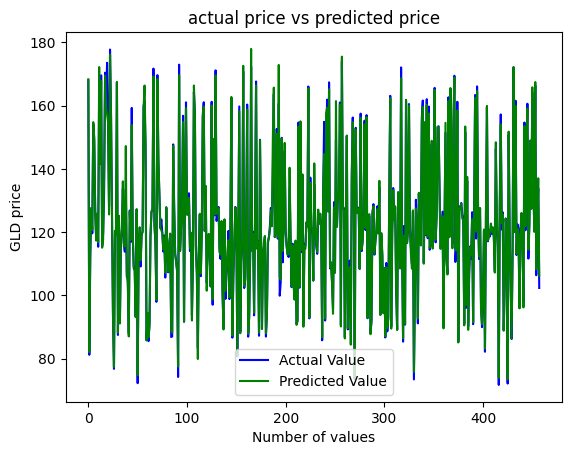

In [61]:
plt.plot(Y_test, color="blue", label="Actual Value")
plt.plot(test_data_prediction, color="green", label="Predicted Value")
plt.title("actual price vs predicted price")
plt.xlabel("Number of values")
plt.ylabel("GLD price")
plt.legend()
plt.show()